# Car Price Prediction

Dataset features
1. car brand
2. year
3. sold price
4. present price
5. KMS driven
6. Fuel type
7. seller type
8. transmission type
9. owners

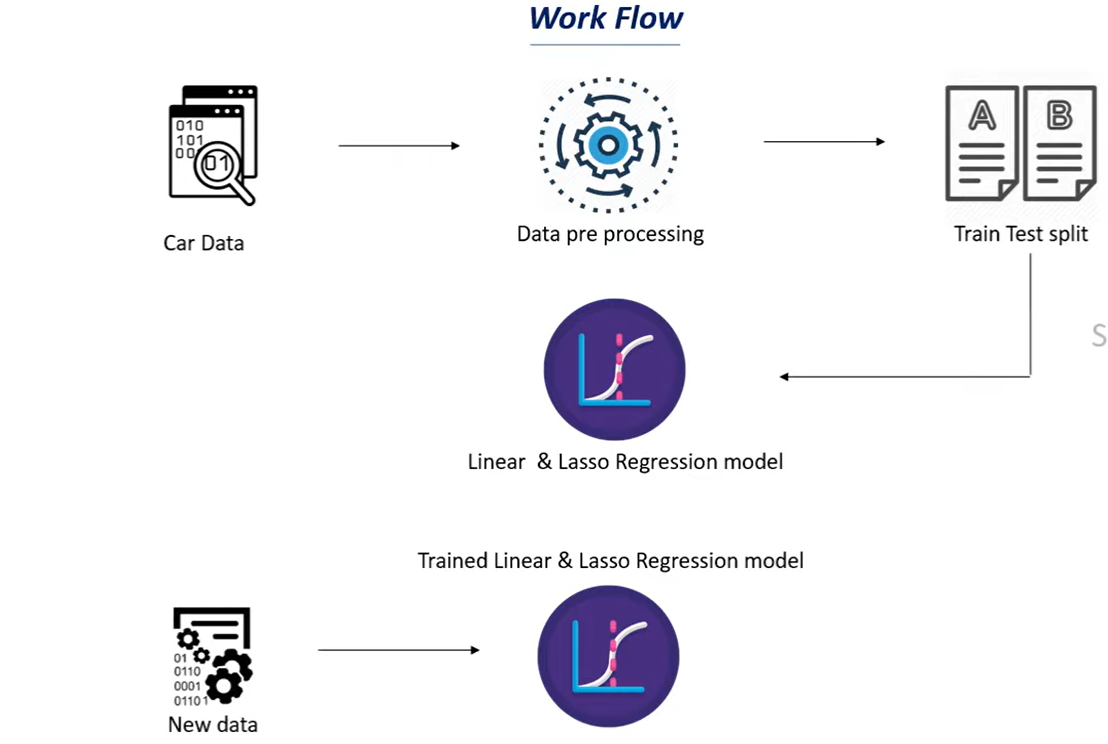

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho


In [3]:
print(os.listdir(path))

['car data.csv', 'car details v4.csv', 'CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv']


In [4]:
csv_file_path = os.path.join(path, 'car data.csv')
df = pd.read_csv(csv_file_path)

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
# checking the number of missing values
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [9]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [10]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [11]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [12]:
# encoding the categorical data

# petrol -> 0
# diesel -> 1
# CNG -> 2

df.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)


/tmp/ipython-input-1839338958.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)


In [13]:
# dealer -> 1
# individual -> 2

df.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)


/tmp/ipython-input-1459730220.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)


In [14]:
# manual -> 1
# automatic -> 2
df.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

/tmp/ipython-input-235573389.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)


In [15]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [16]:
# splitting data into training and test data

X = df.drop(['Car_Name', 'Selling_Price'], axis =1)
Y = df['Selling_Price']

In [17]:
print(X)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [18]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1, random_state=2)

In [20]:
X_train.shape

(270, 7)

In [21]:
X_test.shape

(31, 7)

In [22]:
# linear regression
lin_reg_model = LinearRegression()

In [23]:
lin_reg_model.fit(X_train, Y_train)

LinearRegression()

In [24]:
# model evalutaion

# prediction on training data
training_data_prediction = lin_reg_model.predict(X_train)

In [25]:
# R squared error
error_score = metrics.r2_score(Y_train, training_data_prediction)

In [26]:
print("R squuared error : ", error_score)

R squuared error :  0.8799451660493711


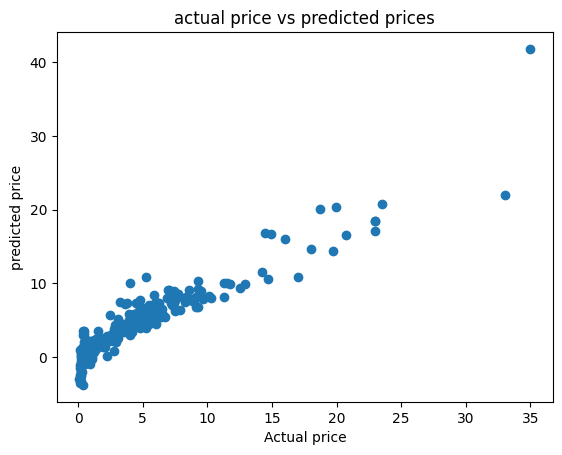

In [27]:
# plot the results

plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("actual price vs predicted prices")
plt.show()

In [28]:
test_data_prediction = lin_reg_model.predict(X_test)

In [29]:
error_score = metrics.r2_score(Y_test, test_data_prediction)

In [30]:
print(error_score)

0.8365766715027051


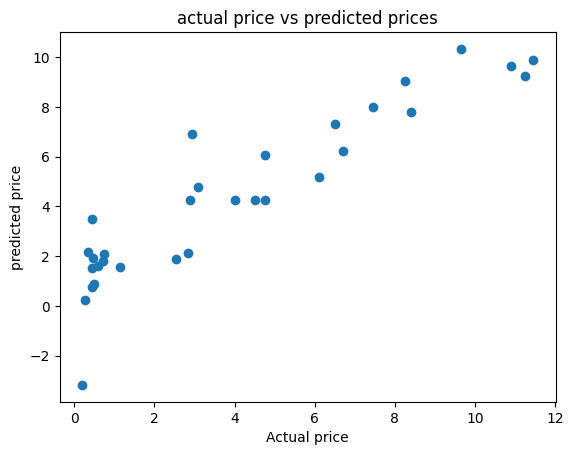

In [31]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("actual price vs predicted prices")
plt.show()

In [32]:
# lasso regression

lass_reg_model = Lasso()
lass_reg_model.fit(X_train, Y_train)

Lasso()

In [33]:
training_data_lasso_prediction = lass_reg_model.predict(X_train)
error_score_lasso = metrics.r2_score(Y_train, training_data_lasso_prediction)

In [34]:
print(error_score_lasso)

0.8427856123435794


In [35]:
# we do the same whole process with lasso regression.